In [3]:
import numpy as np
import os
import pickle
import shutil
from tensorflow.keras import applications, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D, Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split
import cv2
from tensorflow.keras.models import load_model
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from IPython.display import Video
from tqdm import tqdm
from shapely.geometry import Polygon
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
os.chdir('/content/car-parking-detection')

In [5]:
# Configuration
source_root = 'cropped_img'
base_dir = 'prepared_data'
# Clean up existing prepared_data if any
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Your new 2 classes
classes = ['Reserved', 'Unreserved']

# Create destination folders
for split in ['train', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Process Files
for cls in classes:
    src_path = os.path.join(source_root, cls)

    # Check if folder exists
    if not os.path.exists(src_path):
        print(f"Warning: Folder {src_path} not found. Skipping...")
        continue

    # List all images
    files = [f for f in os.listdir(src_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(files) == 0:
        print(f"No images found in {src_path}")
        continue

    # Split 80% train, 20% test
    train_files, test_files = train_test_split(files, test_size=0.20, random_state=42)

    # Helper function to copy
    def copy_files(file_list, split_name):
        for f in file_list:
            src = os.path.join(src_path, f)
            dst = os.path.join(base_dir, split_name, cls, f)
            shutil.copy(src, dst)

    copy_files(train_files, 'train')
    copy_files(test_files, 'test')

print(f"Data reorganized successfully! Classes: {classes}")

Data reorganized successfully! Classes: ['Reserved', 'Unreserved']


In [24]:
img_width, img_height = 40, 65
train_data_dir = 'prepared_data/train'
validation_data_dir = 'prepared_data/test'
batch_size = 32
epochs = 35

# Data Augmentation helps "equilibrate" the learning process
# by creating variations of minority classes
train_datagen = ImageDataGenerator(
    rescale=1./255,
    # rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    # added:
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    interpolation='lanczos'
)

validation_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    interpolation='lanczos'
)

# This handles the "equilibrated" weight calculation automatically
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
train_class_weights = dict(enumerate(class_weights))

print(f"Weights to balance classes: {train_class_weights}")

Found 398 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Weights to balance classes: {0: np.float64(0.796), 1: np.float64(1.3445945945945945)}


In [25]:
# base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# base_model = applications.EfficientNetB0(weights='imagenet',
                                          # include_top=False,
                                          # input_shape=(img_width, img_height, 3))
base_model = applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_width, img_height, 3)
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.25), # Réduit un peu pour éviter l'underfitting
    Dense(1, activation='sigmoid') # On reste en binaire
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=['accuracy'])
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/tmp/ipykernel_4379/3098536573.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 1,854,593 (7.07 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [27]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    class_weight=train_class_weights,
    callbacks=[
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
        callbacks.EarlyStopping(patience=10, monitor='val_loss', restore_best_weights=True),
        callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')
    ]
)

model.save('parking_model_v1.h5')

Epoch 1/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4454 - loss: 0.9068

13/13 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.4623 - loss: 0.8704 - val_accuracy: 0.6300 - val_loss: 0.7853 - learning_rate: 1.0000e-05
Epoch 2/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5605 - loss: 0.7265

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.5905 - loss: 0.6798 - val_accuracy: 0.7400 - val_loss: 0.5367 - learning_rate: 1.0000e-05
Epoch 3/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7138 - loss: 0.5306

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.6910 - loss: 0.5385 - val_accuracy: 0.8400 - val_loss: 0.4064 - learning_rate: 1.0000e-05
Epoch 4/35
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7786 - loss: 0.4439

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.8166 - loss: 0.4071 - val_accuracy: 0.8800 - val_loss: 0.3350 - learning_rate: 1.0000e-05
Epoch 5/35
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8559 - loss: 0.3854

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9824 - loss: 0.0640 - val_accuracy: 0.9900 - val_loss: 0.0824 - learning_rate: 1.0000e-05
Epoch 32/35
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9717 - loss: 0.0669

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9799 - loss: 0.0557 - val_accuracy: 0.9900 - val_loss: 0.0815 - learning_rate: 1.0000e-05
Epoch 33/35
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9813 - loss: 0.0657

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9874 - loss: 0.0587 - val_accuracy: 0.9900 - val_loss: 0.0801 - learning_rate: 1.0000e-05
Epoch 34/35
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9952 - loss: 0.0341

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9950 - loss: 0.0421 - val_accuracy: 0.9900 - val_loss: 0.0792 - learning_rate: 1.0000e-05
Epoch 35/35
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9843 - loss: 0.0626

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.9874 - loss: 0.0606 - val_accuracy: 0.9900 - val_loss: 0.0786 - learning_rate: 1.0000e-05


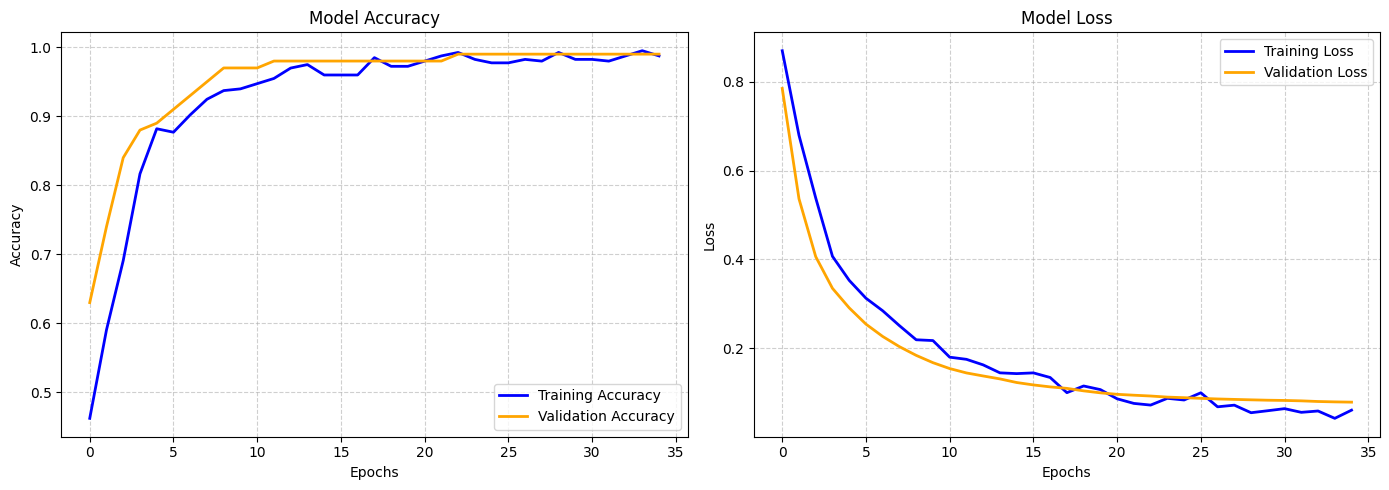

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# 2. Create the plots
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Save and show
plt.tight_layout()

In [ ]:
# 1. LOAD DATA & MODEL
model = load_model('parking_model_v1.h5')

In [ ]:
with open('./car_position_parking.pkl', 'rb') as f:
    posList = pickle.load(f)

# Box dimensions
width, height = 40, 65

In [ ]:
# 2. VIDEO SETUP
cap = cv2.VideoCapture('parking.mp4')
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('processed.mp4', fourcc, fps, (frame_w, frame_h))

# --- CONFIGURATION ---
SKIP_FRAMES = 2
last_results = []

def checkParkingSpace(img):
    img_crops = []
    active_positions = []

    for pos in posList:
        x, y = pos
        imgCrop = img[y:y + height, x:x + width]

        if imgCrop.size == 0 or imgCrop.shape[0] < 5 or imgCrop.shape[1] < 5:
            continue

        imgResize = cv2.resize(imgCrop, (48, 48), interpolation=cv2.INTER_LANCZOS4)
        imgNormalized = imgResize.astype('float32') / 255.0
        img_crops.append(imgNormalized)
        active_positions.append(pos)

    if len(img_crops) > 0:
        batch_array = np.array(img_crops)
        predictions = model.predict(batch_array, verbose=0)
        class_indices = np.argmax(predictions, axis=1)
        return list(zip(active_positions, class_indices))
    return []

# 3. MAIN PROCESSING LOOP (Full Video)
for frame_idx in tqdm(range(total_frames), desc="Processing Full Video"):
    success, frame = cap.read()
    if not success:
        break

    # Update AI results every SKIP_FRAMES
    if frame_idx % SKIP_FRAMES == 0:
        last_results = checkParkingSpace(frame)

    # DRAWING LOGIC (3 CLASSES)
    for pos, class_idx in last_results:
        x, y = pos

        # 0: Reserved, 1: Unreserved
        if class_idx == 0:   # Reserved
            color, thickness = (0, 0, 255), 2  # Red
        else:                # Unreserved (1)
            color, thickness = (0, 255, 0), 2  # Green

        cv2.rectangle(frame, (x, y), (x + width, y + height), color, thickness)

    out.write(frame)

cap.release()
out.release()

Processing Full Video: 100%|██████████| 701/701 [02:43<00:00,  4.28it/s]


In [ ]:
def check_collision(moving_box_coords, pos_list, w, h):
    mx1, my1, mx2, my2 = moving_box_coords

    # ADJUSTMENT: Use bottom 50% instead of 20% for more sensitivity
    foot_y1 = my2 - (my2 - my1) * 0.5
    moving_shape = box(mx1, foot_y1, mx2, my2)

    for i, (px, py) in enumerate(pos_list):
        spot_shape = box(px, py, px + w, py + h)

        if moving_shape.intersects(spot_shape):
            # REDUCE THIS: 300 might be too much for a small scratch/touch
            # Let's try 50 pixels of overlap
            if moving_shape.intersection(spot_shape).area > 50:
                return i
    return None

In [ ]:
# --- CALLBACK FUNCTIONS ---
def on_crash(car_id1, car_id2, frame_num):
    # This prints only when the temporal threshold is met
    print(f"\n[ALERT] Frame {frame_num}: Sustained contact detected between ID:{car_id1} and ID:{car_id2}!")

collision_callbacks = [on_crash]

# --- GEOMETRIC LOGIC CLASS ---
class GeometricCollisionDetector:
    def __init__(self, callbacks, prox_thresh=200, frame_buffer=4):
        self.callbacks = callbacks
        self.prox_thresh = prox_thresh
        self.frame_buffer = frame_buffer  # Number of consecutive frames required
        self.active_collisions = set()
        self.hit_counters = {} # Tracks: {(id1, id2): count}

    def check(self, results, frame_num):
        self.active_collisions.clear()
        if results[0].obb is None or results[0].obb.id is None:
            return

        boxes = results[0].obb.xyxyxyxy.cpu().numpy()
        ids = results[0].obb.id.cpu().numpy().astype(int)

        # Create polygons for current frame
        active_frame_cars = {ids[i]: Polygon(boxes[i]) for i in range(len(ids))}

        # Keep track of which pairs touched THIS frame
        current_frame_pairs = set()

        for m_id, m_poly in active_frame_cars.items():
            for o_id, o_poly in active_frame_cars.items():
                if m_id >= o_id: continue

                # Broad Phase: Fast distance check
                if m_poly.centroid.distance(o_poly.centroid) < self.prox_thresh:

                    # Narrow Phase: Shrink by 3 pixels to handle "widening" box noise
                    # If they still touch after shrinking, it's a high-confidence contact
                    if m_poly.buffer(-3.0).intersects(o_poly.buffer(-3.0)):
                        pair = (m_id, o_id)
                        current_frame_pairs.add(pair)

                        # Increment the counter for this pair
                        self.hit_counters[pair] = self.hit_counters.get(pair, 0) + 1

                        # Only flag as collision if it persists for 'frame_buffer' frames
                        if self.hit_counters[pair] >= self.frame_buffer:
                            self.active_collisions.add(m_id)
                            self.active_collisions.add(o_id)

                            # Fire callback exactly when threshold is hit
                            if self.hit_counters[pair] == self.frame_buffer:
                                for func in self.callbacks:
                                    func(m_id, o_id, frame_num)

        # Reset counters for pairs that stopped touching
        # This clears "flickers" that lasted only 1 or 2 frames
        for pair in list(self.hit_counters.keys()):
            if pair not in current_frame_pairs:
                self.hit_counters[pair] = 0

# --- CUSTOM DRAWING FUNCTION ---
def draw_custom_annotations(frame, results, collision_ids):
    if results[0].obb is None or results[0].obb.id is None:
        return frame

    boxes = results[0].obb.xyxyxyxy.cpu().numpy().astype(np.int32)
    ids = results[0].obb.id.cpu().numpy().astype(int)

    for i, box in enumerate(boxes):
        car_id = ids[i]

        # Red if confirmed collision, Green if safe
        color = (0, 0, 255) if car_id in collision_ids else (0, 255, 0)

        cv2.polylines(frame, [box], isClosed=True, color=color, thickness=2)

        # Positioning ID label
        top_left_point = box[box[:, 1].argmin()]
        label = f"ID:{car_id}"

        (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(frame, (top_left_point[0], top_left_point[1] - h - 10),
                      (top_left_point[0] + w, top_left_point[1]), color, -1)
        cv2.putText(frame, label, (top_left_point[0], top_left_point[1] - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

    return frame

# --- MAIN EXECUTION ---
video_input = "crash-1.mp4"
video_output = "crash-1-processed.mp4"

model = YOLO('yolov8n-obb.pt')
cap = cv2.VideoCapture(video_input)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_output, fourcc, fps, (width, height))

# Added frame_buffer=4 to filter out millisecond flickers
detector = GeometricCollisionDetector(callbacks=collision_callbacks, prox_thresh=200, frame_buffer=4)

for frame_idx in tqdm(range(total_frames), desc="Processing Video"):
    success, frame = cap.read()
    if not success: break

    # Using BoT-SORT can also help with ID stability if ByteTrack is jumpy
    results = model.track(frame, persist=True, tracker="bytetrack.yaml", verbose=False)

    detector.check(results, frame_idx)
    annotated_frame = draw_custom_annotations(frame, results, detector.active_collisions)
    out.write(annotated_frame)

cap.release()
out.release()
print(f"\nProcessing complete. File saved as {video_output}")

Processing Video:   0%|          | 0/302 [00:00<?, ?it/s]

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 223ms
Prepared 1 package in 57ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



Processing Video:   2%|▏         | 6/302 [00:11<08:35,  1.74s/it]


[ALERT] Frame 6: Sustained contact detected between ID:98 and ID:190!


Processing Video:   2%|▏         | 7/302 [00:13<07:56,  1.62s/it]

...


[ALERT] Frame 294: Sustained contact detected between ID:176 and ID:265!


Processing Video:  99%|█████████▊| 298/302 [07:18<00:05,  1.48s/it]


[ALERT] Frame 298: Sustained contact detected between ID:145 and ID:308!


Processing Video: 100%|██████████| 302/302 [07:23<00:00,  1.47s/it]


Processing complete. File saved as crash-1-processed.mp4
